# Image Digit Classification

## 1. Data Processing


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

- Reshape 1D arrays into 2D arrays.
- Separate image data and labels into distinct variables (processed_images, labels).

In [3]:
df = pd.read_csv("mnist_dataset.csv")
processed_images = []
labels = []
columns = df.columns
for index,row in df.iterrows():
    size = 28
    image = []
    label = row["label"]
    for i in range(size):
        image_row = []
        for j in range(size):
            image_row.append(0)
        image.append(image_row)

    for column in columns:
        splited_column = column.split("x")
        if not len(splited_column) == 2:
            continue
        x = int(splited_column[0])-1
        y = int(splited_column[1])-1
        image[x][y] = row[column]

    labels.append(label)
    processed_images.append(image)

In [4]:
X = np.array(processed_images)
y = np.array(labels)

In [33]:
print(f"Dataset size: {X.shape[0]}")
print(f"proccesed images shape: {X.shape[1:]}")

Dataset size: 30000
proccesed images shape: (28, 28, 1)


Data reshaping and normalization

In [6]:
X = np.expand_dims(X, axis=-1)
X = X / 255.0 # from gray color range [0,255] to [0,1]

Label distribution in the dataset:

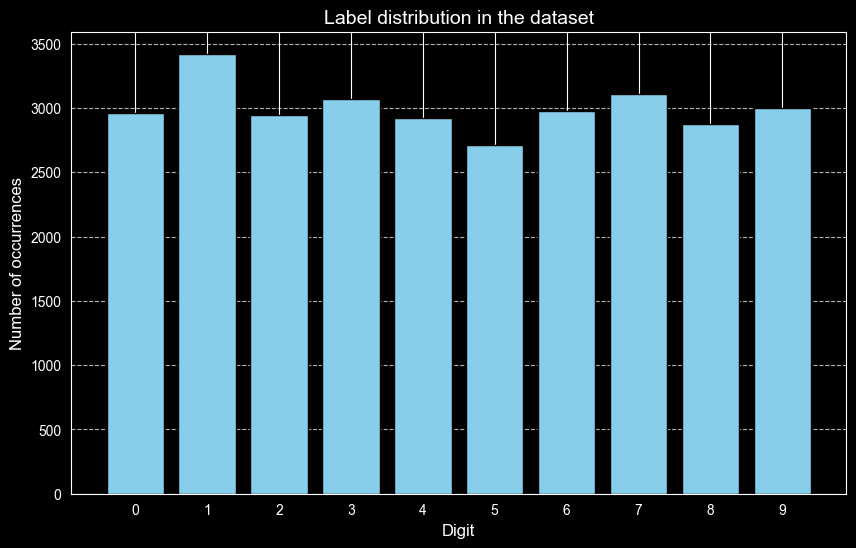

In [7]:
counted_labels = pd.DataFrame(labels).value_counts().sort_index()
plt.figure(figsize=(10, 6))

classes = [str(i[0]) for i in counted_labels.index]
counts = counted_labels.values

plt.bar(classes, counts, color='skyblue', edgecolor='black')

plt.title("Label distribution in the dataset", fontsize=14)
plt.xlabel("Digit", fontsize=12)
plt.ylabel("Number of occurrences", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

The data is evenly distributed, which is ideal for machine learning.

## Images grid for visualization

In [8]:
def show_images_grid(images, labels, rows=4, cols=5):

    num_available = len(images)
    n_to_show = min(num_available, rows * cols)

    plt.figure(figsize=(2 * cols, 2 * rows))

    for i in range(n_to_show):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(labels[i], fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### Examples

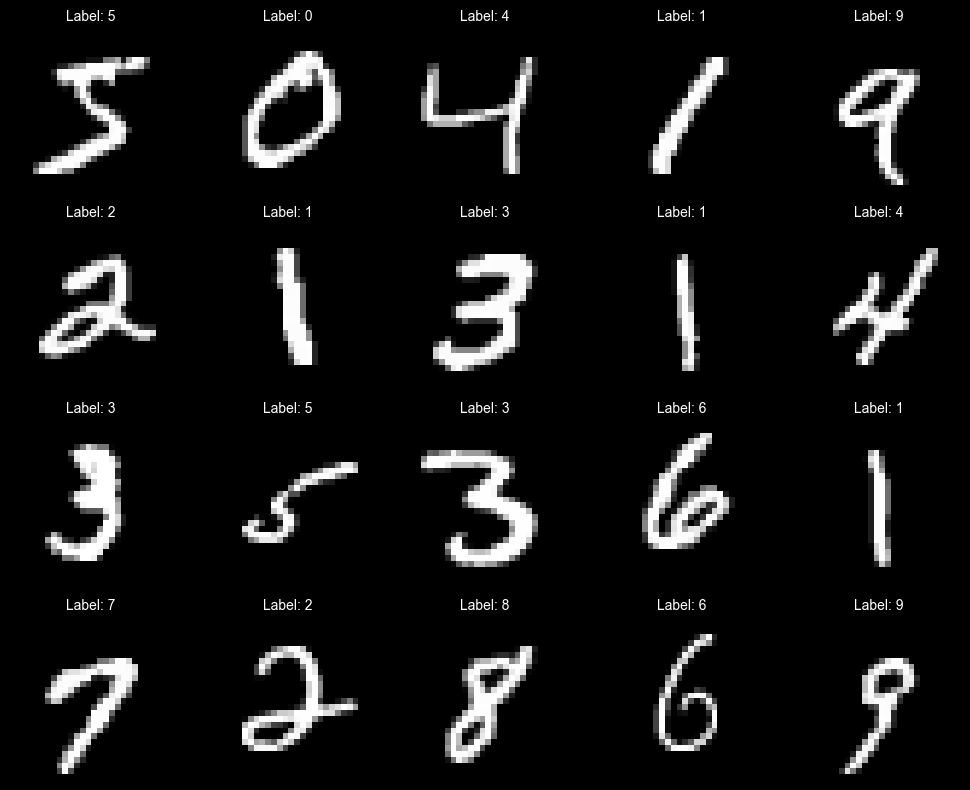

In [9]:
sample = 0

sample_size = 20
labels = y[sample*sample_size:(sample+1)*sample_size]
labels = [f"Label: {labels[i]}" for i in range(len(labels))]

images = processed_images[sample*sample_size:(sample+1)*sample_size ]

show_images_grid(images,labels )

## 2. Model

### Architecture

In [10]:
import torch
from torch import nn

In [11]:
class Model(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, 3,),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units*2, 3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=20*5*5, out_features=300),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=300, out_features=output_shape),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Model(
    input_shape=1,
    hidden_units=10,
    output_shape=10
).to(device=device)

model

Model(
  (conv_block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=500, out_features=300, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=300, out_features=10, bias=True)
  )
)

In [13]:
from torchinfo import summary
summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [1, 10]                   --
├─Sequential: 1-1                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-1                       [1, 10, 26, 26]           100
│    └─ReLU: 2-2                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-3                    [1, 10, 13, 13]           --
├─Sequential: 1-2                        [1, 20, 5, 5]             --
│    └─Conv2d: 2-4                       [1, 20, 11, 11]           1,820
│    └─ReLU: 2-5                         [1, 20, 11, 11]           --
│    └─MaxPool2d: 2-6                    [1, 20, 5, 5]             --
├─Sequential: 1-3                        [1, 10]                   --
│    └─Flatten: 2-7                      [1, 500]                  --
│    └─Linear: 2-8                       [1, 300]                  150,300
│    └─ReLU: 2-9                         [1, 300]                  --
│    └

### Data prepreration for model learning

In [14]:
from torch.utils.data import TensorDataset, DataLoader

In [15]:
print(f"Images in dataset: {X.shape[0]}")
print(f"shape of each image: {X.shape[1:]}")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

Images in dataset: 30000
shape of each image: (28, 28, 1)


In [16]:
X_test.shape, X_train.shape

((3000, 28, 28, 1), (27000, 28, 28, 1))

In [17]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [18]:
X_test.shape, X_train.shape

(torch.Size([3000, 28, 28, 1]), torch.Size([27000, 28, 28, 1]))

In [19]:
X_train = X_train.permute(0, 3, 1, 2)
X_test = X_test.permute(0, 3, 1, 2)

In [20]:
train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)

In [21]:
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

In [22]:
print(f"Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Length of train_dataloader: 844 batches of 32
Length of test_dataloader: 94 batches of 32


### Learning loop

In [23]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

In [24]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.001, momentum=0.9)

In [25]:
epochs = 30

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}")
  ### Training
  train_loss = 0

  for batch_idx, (X_temp, y_temp) in enumerate(train_dataloader):
    model.train()
    y_pred = model(X_temp)

    loss = loss_fn(y_pred, y_temp.long())
    train_loss += loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_dataloader)

  ### Testing
  test_loss, test_acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X_test_temp, y_test_temp in test_dataloader:
      test_pred = model(X_test_temp)
      test_loss += loss_fn(test_pred, y_test_temp.long())
      test_acc += accuracy_score(y_test_temp, test_pred.argmax(dim=1)) * 100

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)


  print(f"Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}\n---")



  0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 0
Train loss: 1.5174 | Test loss: 0.5106, Test acc: 85.2283
---
Epoch: 1
Train loss: 0.4529 | Test loss: 0.3239, Test acc: 90.6804
---
Epoch: 2
Train loss: 0.3140 | Test loss: 0.2477, Test acc: 92.5310
---
Epoch: 3
Train loss: 0.2468 | Test loss: 0.1827, Test acc: 94.2265
---
Epoch: 4
Train loss: 0.2065 | Test loss: 0.1547, Test acc: 95.4676
---
Epoch: 5
Train loss: 0.1768 | Test loss: 0.1381, Test acc: 96.0660
---
Epoch: 6
Train loss: 0.1534 | Test loss: 0.1267, Test acc: 96.0993
---
Epoch: 7
Train loss: 0.1360 | Test loss: 0.1186, Test acc: 96.3985
---
Epoch: 8
Train loss: 0.1266 | Test loss: 0.1087, Test acc: 96.5647
---
Epoch: 9
Train loss: 0.1215 | Test loss: 0.1013, Test acc: 96.6312
---
Epoch: 10
Train loss: 0.1109 | Test loss: 0.0985, Test acc: 96.7974
---
Epoch: 11
Train loss: 0.1025 | Test loss: 0.0929, Test acc: 97.1631
---
Epoch: 12
Train loss: 0.0955 | Test loss: 0.0938, Test acc: 97.1853
---
Epoch: 13
Train loss: 0.0908 | Test loss: 0.0859, Test acc: 97.3958
---
Ep

### Saving Best model

In [26]:
torch.save(model.state_dict(), 'model_weights.pth')

## 3. Testing the model

In [27]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Load model weights if the model is not trained.

In [28]:
if not model:
    model = Model(
        input_shape=1,
        hidden_units=10,
        output_shape=10
    ).to(device=device)
    
    model.load_state_dict(torch.load('model_weights.pth'))
    model.eval()

In [29]:
with torch.inference_mode():
    y_pred = model(X_test)

y_pred = np.argmax(y_pred, axis=1)
print(f"Model accuracy on test data: {accuracy_score(y_test, y_pred):.2%}")

Model accuracy on test data: 98.07%


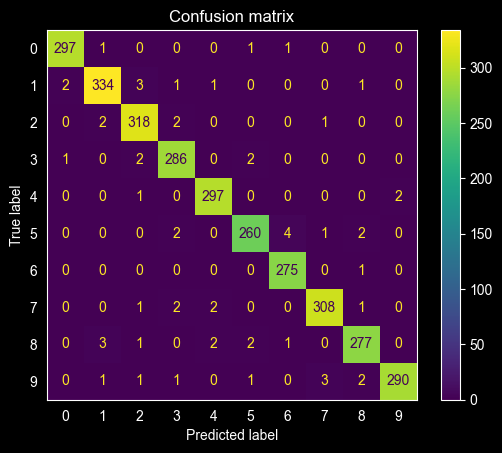

In [30]:
conf_matrix = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = list(range(10)))

cm_display.plot()
plt.title("Confusion matrix")
plt.grid(False)
plt.show()

### Peek at incorrect predictions


In [31]:
incorrect_indexes = np.where( y_test != y_pred)
print(f"Incorrect predictions: {len(incorrect_indexes[0])}")

sample = 0
sample_size = 20

start = sample*sample_size
end = (sample+1)*sample_size

y_test_wrong = y_test[incorrect_indexes][start:end]
y_pred_wrong = y_pred[incorrect_indexes][start:end]
X_test_wrong = X_test[incorrect_indexes][start:end]

Incorrect predictions: 58


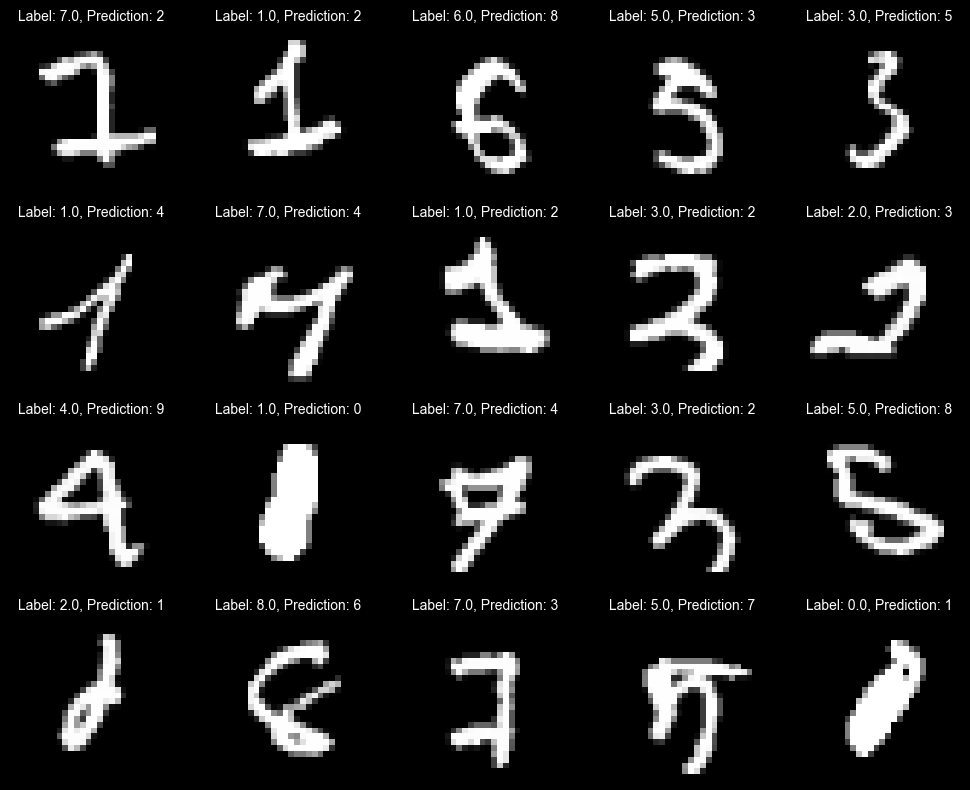

In [32]:
X_test_wrong = X_test_wrong.permute(0, 2, 3, 1)
labels = [f"Label: {y_test_wrong[i]}, Prediction: {y_pred_wrong[i]}" for i in range(start,end )]

show_images_grid(X_test_wrong, labels)